In [12]:
from hossam import load_data
from helpers import *
from pandas import DataFrame
import pandas as pd
from IPython.display import display, Markdown

import os               # 파일 및 디렉토리 경로를 처리하는 파이썬 내장 모듈
import joblib           # 학습된 모델을 파일로 저장하고 복원하는 직렬화 모듈
import numpy as np      # 수치계산을 위한 파이썬 내장 모듈
import glob as gl       # 파일 목록을 리스트로 반환하는 파이썬 내장 모듈
import datetime as dt   # 날짜 및 시간 처리를 위한 파이썬 내장 모듈

# 훈련, 검증 데이터 분리 함수
from sklearn.model_selection import train_test_split

# 성능평가 지표 계산 함수
from sklearn.metrics import (
    r2_score,                           # 결정계수 (R2)
    mean_absolute_error,                # 평균절대오차 (MAE)
    mean_squared_error,                 # 평균제곱오차 (MSE)
    mean_squared_log_error,             # 평균제곱로그오차 (MSLE)
    mean_absolute_percentage_error      # 평균절대백분율오차 (MAPE)
)

# 선형 계열 모델
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

# 비선형 계열 모델
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# 트리계열 모델
from sklearn.tree import DecisionTreeRegressor

# 앙상블 모델
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [13]:
# 분석용 데이터 전처리가 완료된 데이터 셋
origin = pd.read_excel("local_features_log_labeled.xlsx")
df = my_qtcheck.set_type(origin, as_category=["spatial_cluster", "년도", "기준월"])

<class 'pandas.DataFrame'>
RangeIndex: 6240 entries, 0 to 6239
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   부동산_비율           6240 non-null   float64 
 1   소매_비율            6240 non-null   float64 
 2   예술·스포츠_비율        6240 non-null   float64 
 3   교육_비율            6240 non-null   float64 
 4   월유동인구수           6240 non-null   float64 
 5   spatial_cluster  6240 non-null   category
 6   기준월              6240 non-null   category
 7   년도               6240 non-null   category
 8   매출금액             6240 non-null   float64 
dtypes: category(3), float64(6)
memory usage: 311.1 KB


## 4. 데이터에서 독립변수와 종속변수 분리
### 머신러닝에서는 독립변수를 feature, 종속변수를 target으로 명명한다.

In [14]:
feature = df.drop(columns=["매출금액"])
target = df["매출금액"]
feature.shape, target.shape

((6240, 8), (6240,))

## 5. 훈련, 검증 데이터 분리

In [15]:
# 훈련, 검증 데이터 분리
# 분류 문제인 경우 파라미터 추가 --> stratify=target
x_train, x_test, y_train, y_test = train_test_split(feature, target, test_size=0.2, random_state=RANDOM_STATE)

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((4992, 8), (1248, 8), (4992,), (1248,))

## 6. 학습을 완료한 모델이 저장될 폴더

In [16]:
project_name = "local"
base_dir = f"{project_name}/baseline"

if not os.path.exists(base_dir):
    os.makedirs(base_dir)

작업 폴더: local\baseline
학습 완료 [ 1/11] : linear
학습 완료 [ 2/11] : ridge
학습 완료 [ 3/11] : lasso
학습 완료 [ 4/11] : elasticnet
학습 완료 [ 5/11] : kneighbors
학습 완료 [ 6/11] : svr
학습 완료 [ 7/11] : decisiontree
학습 완료 [ 8/11] : randomforest
학습 완료 [ 9/11] : xgb
학습 완료 [10/11] : lgbm
학습 완료 [11/11] : catboost


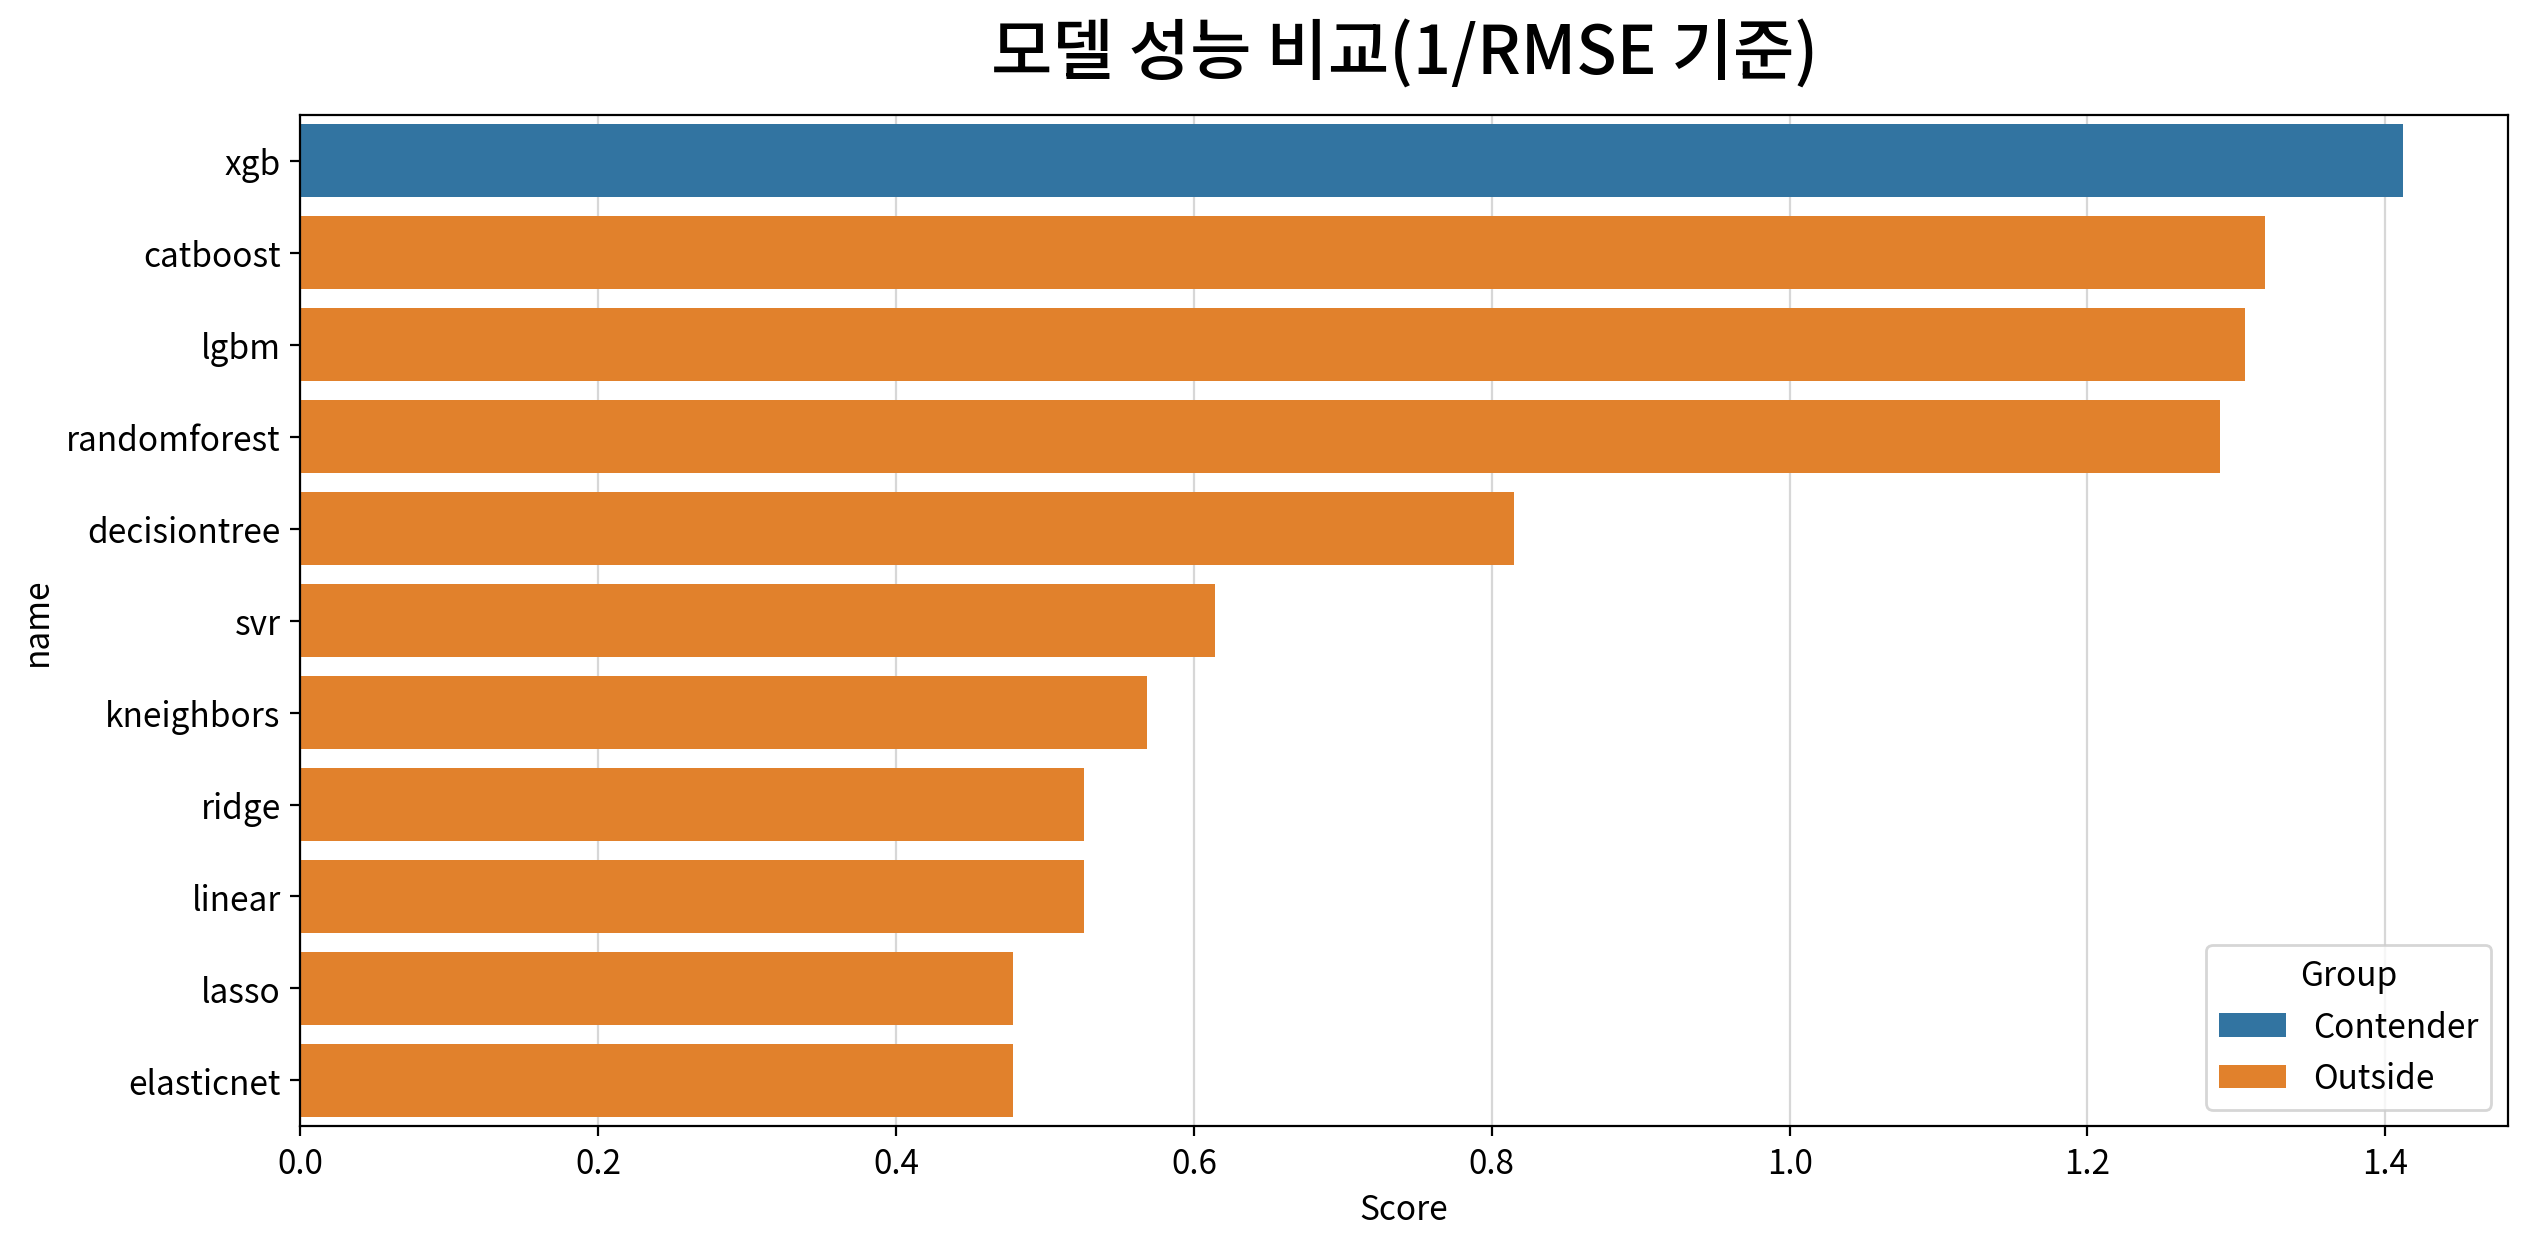


모델 11개 학습·저장 완료 → local\baseline


,Rank,Group,Model,R2,MAE,MSE,RMSE,RMSLE,MAPE,MPE,RMSE_Gap,Score
name,,,,,,,,,,,,
xgb,1,Contender,XGBRegressor,0.885,0.471,0.502,0.708,0.050,0.035,-0.005,0.000,1.412
catboost,2,Outside,CatBoostRegressor,0.868,0.531,0.575,0.758,0.053,0.040,-0.007,0.070,1.319
lgbm,3,Outside,LGBMRegressor,0.866,0.536,0.587,0.766,0.055,0.040,-0.008,0.081,1.306
randomforest,4,Outside,RandomForestRegressor,0.862,0.488,0.602,0.776,0.054,0.037,-0.008,0.095,1.289
decisiontree,5,Outside,DecisionTreeRegressor,0.655,0.664,1.506,1.227,0.082,0.050,-0.009,0.732,0.815
svr,6,Outside,SVR,0.394,1.027,2.649,1.628,0.107,0.074,-0.006,1.298,0.614
kneighbors,7,Outside,KNeighborsRegressor,0.293,1.214,3.092,1.758,0.117,0.089,-0.016,1.482,0.569
ridge,8,Outside,Ridge,0.173,1.324,3.613,1.901,0.126,0.097,-0.020,1.684,0.526
linear,9,Outside,LinearRegression,0.173,1.324,3.614,1.901,0.126,0.097,-0.020,1.684,0.526


CPU times: total: 1min 52s
Wall time: 37.5 s


In [17]:
%%time
my_ml.reg_baseline("local", x_train, y_train, x_test, y_test)

## 튜닝 저장폴더 구성

In [18]:
tuned_dir = f"{project_name}/tuned"

if not os.path.exists(tuned_dir):
    os.makedirs(tuned_dir)

In [19]:
# 튜닝하기 원하는 모델을 로드하여 딕셔너리 형태로 저장
models = {
    "linear": my_ml.load_model(f"{base_dir}/linear.pkl"),
    "ridge": my_ml.load_model(f"{base_dir}/ridge.pkl"),
    "lasso": my_ml.load_model(f"{base_dir}/lasso.pkl"),
    "elasticnet": my_ml.load_model(f"{base_dir}/elasticnet.pkl"),
    "kneighbors": my_ml.load_model(f"{base_dir}/kneighbors.pkl"),
    "svr": my_ml.load_model(f"{base_dir}/svr.pkl"),
    "decisiontree": my_ml.load_model(f"{base_dir}/decisiontree.pkl"),
    "randomforest": my_ml.load_model(f"{base_dir}/randomforest.pkl"),
    "xgb": my_ml.load_model(f"{base_dir}/xgb.pkl"),
    "lgbm": my_ml.load_model(f"{base_dir}/lgbm.pkl"),
    "catboost": my_ml.load_model(f"{base_dir}/catboost.pkl")
}

작업 폴더: local\tuned
탐색 범위: 실습용(축소)
탐색 완료 [ 1/11] : linear (0.3초, CV RMSE=1.8025)
    최적 조합: {'model__fit_intercept': True, 'model__positive': False}
탐색 완료 [ 2/11] : ridge (0.4초, CV RMSE=1.8024)
    최적 조합: {'model__alpha': 10.0, 'model__solver': 'lsqr'}
탐색 완료 [ 3/11] : lasso (0.4초, CV RMSE=1.8024)
    최적 조합: {'model__alpha': 0.001, 'model__max_iter': 1000}
탐색 완료 [ 4/11] : elasticnet (0.4초, CV RMSE=1.8024)
    최적 조합: {'model__alpha': 0.001, 'model__l1_ratio': 0.2}
탐색 완료 [ 5/11] : kneighbors (0.6초, CV RMSE=1.4492)
    최적 조합: {'model__n_neighbors': 10, 'model__weights': 'uniform'}
탐색 완료 [ 6/11] : svr (4.7초, CV RMSE=1.6114)
    최적 조합: {'model__C': 1.0, 'model__epsilon': 0.2, 'model__gamma': 0.1}
탐색 완료 [ 7/11] : decisiontree (0.5초, CV RMSE=1.0240)
    최적 조합: {'model__max_depth': None, 'model__min_samples_leaf': 1}
탐색 완료 [ 8/11] : randomforest (8.4초, CV RMSE=0.6973)
    최적 조합: {'model__min_samples_leaf': 1, 'model__n_estimators': 300}
탐색 완료 [ 9/11] : xgb (6.3초, CV RMSE=0.6409)
    최적 조합: {'mod

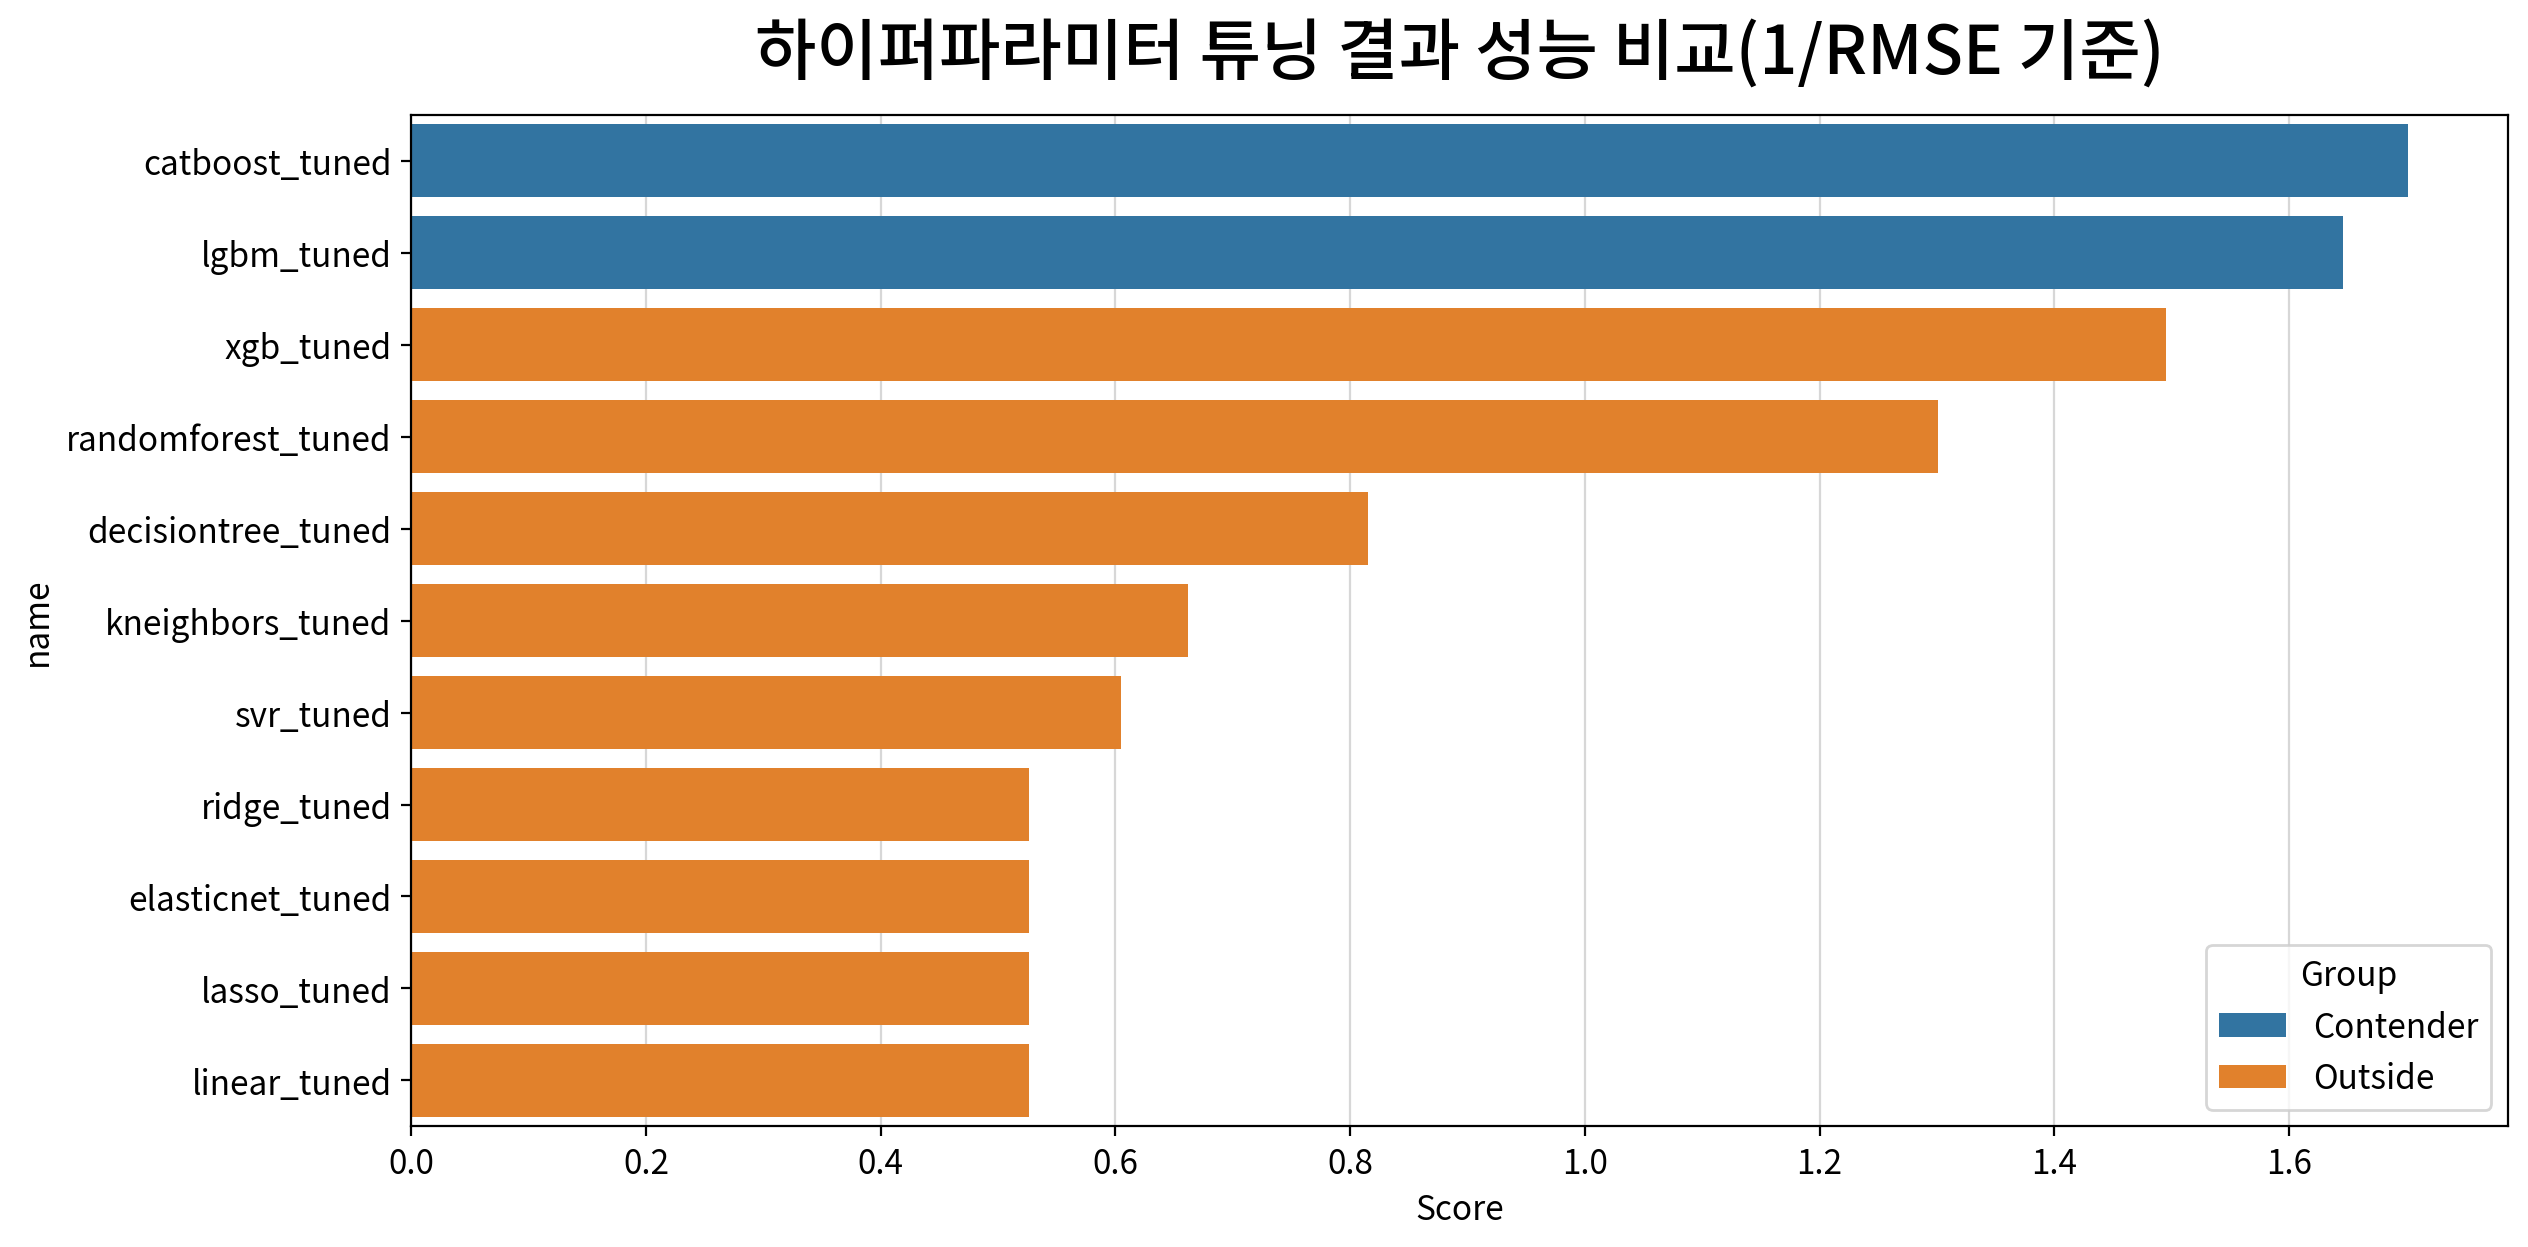


모델 11개 튜닝·저장 완료 → local\tuned


,Rank,Group,Model,R2,MAE,MSE,RMSE,RMSLE,MAPE,MPE,RMSE_Gap,Score
name,,,,,,,,,,,,
catboost_tuned,1,Contender,CatBoostRegressor,0.921,0.404,0.345,0.588,0.042,0.030,-0.004,0.000,1.702
lgbm_tuned,2,Contender,LGBMRegressor,0.916,0.416,0.369,0.607,0.044,0.031,-0.004,0.034,1.646
xgb_tuned,3,Outside,XGBRegressor,0.898,0.455,0.447,0.669,0.048,0.034,-0.004,0.138,1.495
randomforest_tuned,4,Outside,RandomForestRegressor,0.865,0.482,0.591,0.768,0.054,0.036,-0.007,0.308,1.301
decisiontree_tuned,5,Outside,DecisionTreeRegressor,0.655,0.664,1.506,1.227,0.082,0.050,-0.009,1.088,0.815
kneighbors_tuned,6,Outside,KNeighborsRegressor,0.477,1.031,2.284,1.511,0.101,0.076,-0.015,1.571,0.662
svr_tuned,7,Outside,SVR,0.375,1.052,2.731,1.652,0.109,0.076,-0.007,1.812,0.605
ridge_tuned,8,Outside,Ridge,0.174,1.324,3.610,1.900,0.126,0.097,-0.020,2.233,0.526
elasticnet_tuned,9,Outside,ElasticNet,0.174,1.324,3.612,1.900,0.126,0.097,-0.020,2.234,0.526


CPU times: total: 3min 21s
Wall time: 6min 5s


In [20]:
%%time
my_ml.reg_tunes("local", models, x_train, y_train, x_test, y_test, practice=True)

# 5부. 모델을 검증하고 해석하는 단계
### 미션 10. "점수가 배운 것인지 외운 것인지 가른다"

In [21]:
# 독립변수 분리
feature = df.drop(columns=["매출금액"])

# 종속변수 분리
target = df["매출금액"]

# 훈련, 검증 데이터 분리
# 분류 문제인 경우 파라미터 추가 --> stratify=target
x_train, x_test, y_train, y_test = train_test_split(feature, target, test_size=0.2, random_state=RANDOM_STATE)

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((4992, 8), (1248, 8), (4992,), (1248,))

In [22]:
# 튜닝이 완료된 모델이 저장되어 있는 폴더 위치 지정
project_name = "local"
tuned_dir = f"{project_name}/tuned"

if not os.path.exists(tuned_dir):
    os.makedirs(tuned_dir)

In [23]:
models = {
    "catboost": my_ml.load_model(f"{tuned_dir}/catboost_tuned.pkl"),
    "lgbm": my_ml.load_model(f"{tuned_dir}/lgbm_tuned.pkl")
}

#### ▶︎ catboost

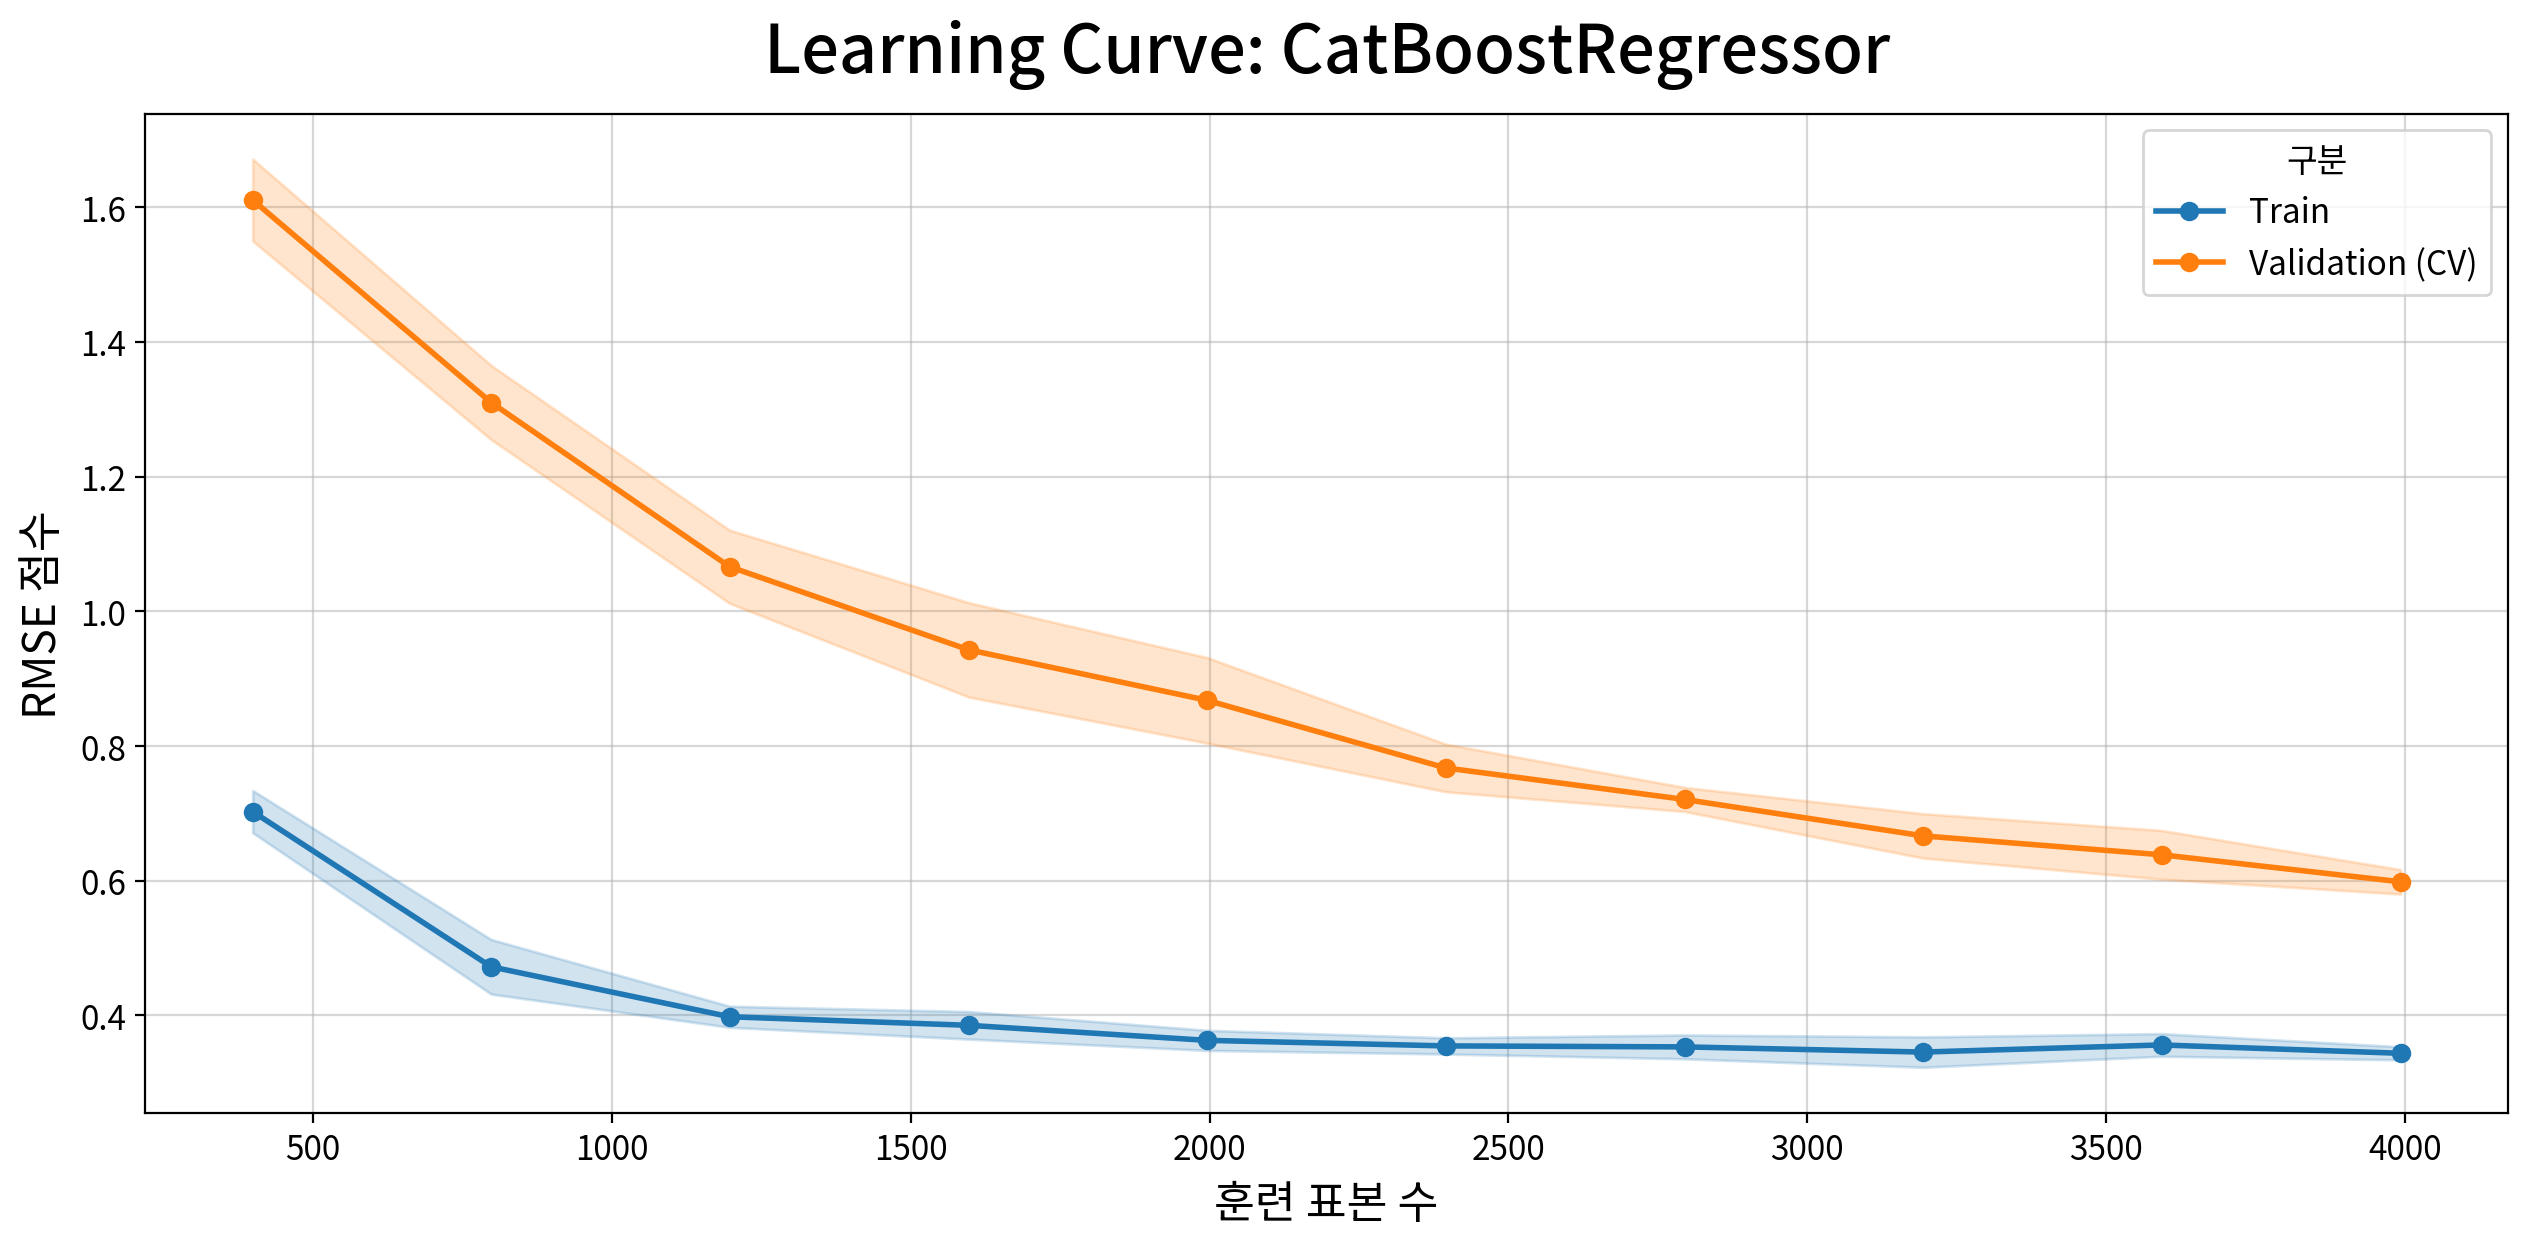

,Train,CV,CV_Std,Test,Gap,Gap%,Overfit
Metric,,,,,,,
RMSE,0.359,0.603,0.023,0.588,0.244,40.470,과대적합
MAE,0.264,0.416,0.016,0.404,0.151,36.450,과대적합
R2,0.969,0.911,0.007,0.921,0.057,5.740,일반화



◆ Fit Diagnosis: CatBoostRegressor  (threshold=20%, 기준=Train↔CV 5-Fold)
   ※ threshold 는 학술 표준이 아닌 경험칙입니다. 임계값보다 학습곡선 추세를 함께 보세요.
  - RMSE    Train=     0.3593  CV=     0.6035 (±0.0227)  Test=     0.5877  Gap%=   40.47%  [과대적합] [주의]
  - MAE     Train=     0.2641  CV=     0.4155 (±0.0164)  Test=     0.4037  Gap%=   36.45%  [과대적합] [주의]
  - R2      Train=     0.9686  CV=     0.9112 (±0.0068)  Test=     0.9210  Gap%=    5.74%  [일반화] [정상]

  ▶ 진단: ⚠ 과대적합 (Overfit · 高분산) - 훈련↔CV 격차가 큼
      · train R2=0.9686 (과소적합 기준 < 0.05) · CV R2=0.9112



#### ▶︎ lgbm

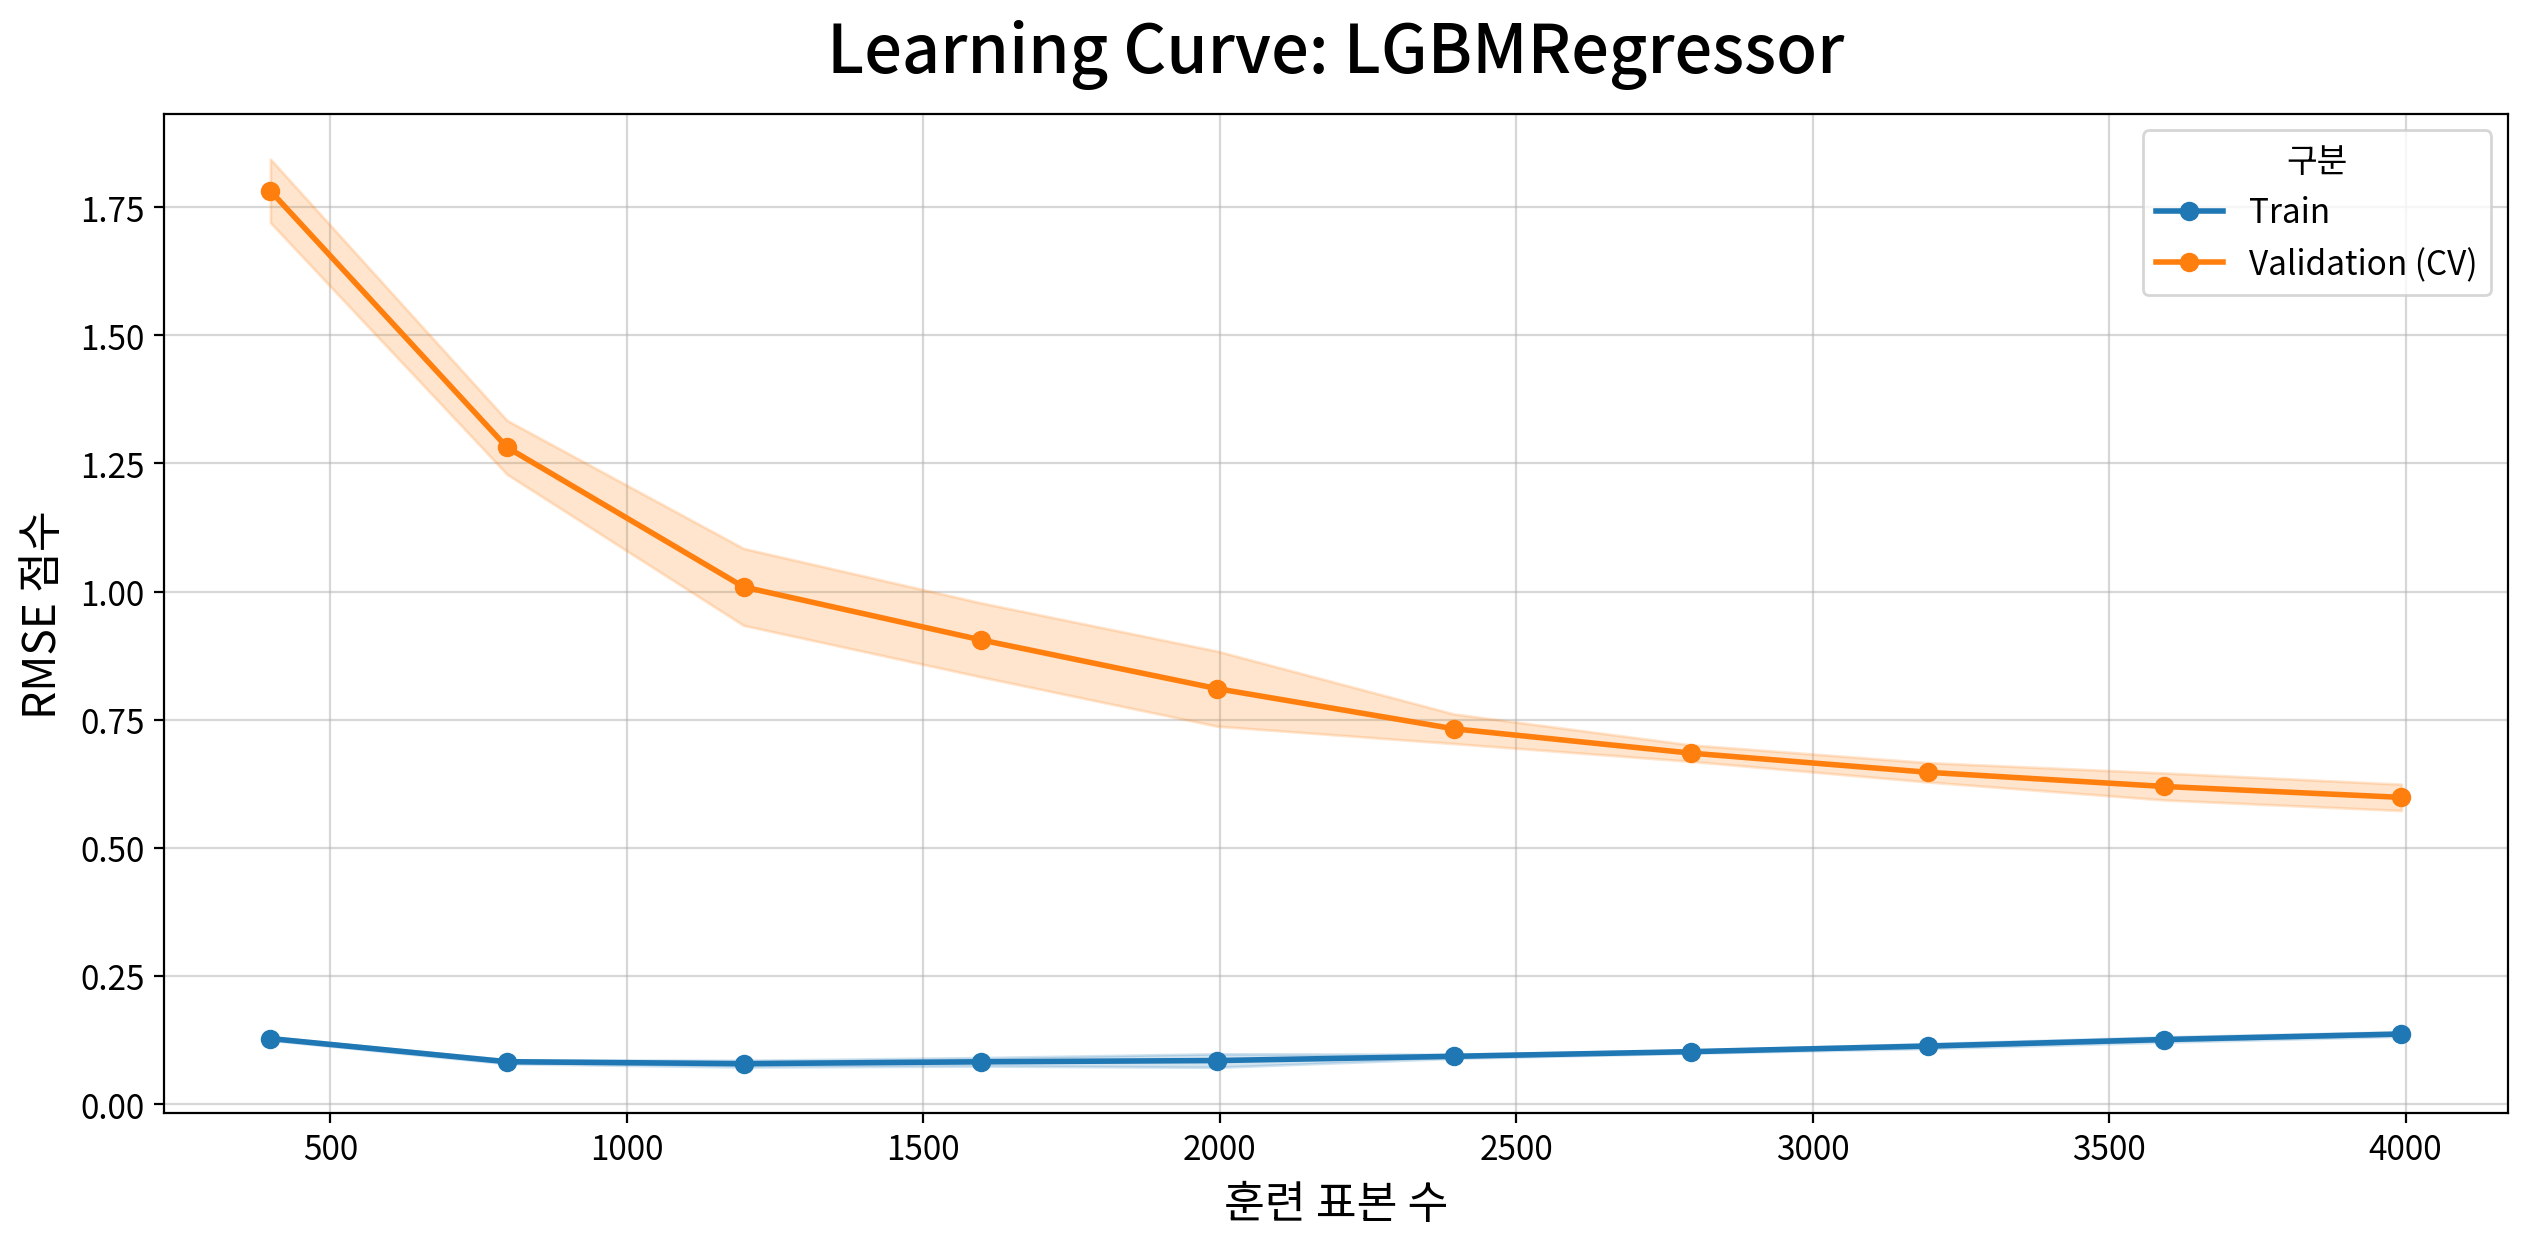

,Train,CV,CV_Std,Test,Gap,Gap%,Overfit
Metric,,,,,,,
RMSE,0.160,0.597,0.026,0.607,0.437,73.220,과대적합
MAE,0.115,0.420,0.016,0.416,0.305,72.610,과대적합
R2,0.994,0.913,0.007,0.916,0.081,8.080,일반화



◆ Fit Diagnosis: LGBMRegressor  (threshold=20%, 기준=Train↔CV 5-Fold)
   ※ threshold 는 학술 표준이 아닌 경험칙입니다. 임계값보다 학습곡선 추세를 함께 보세요.
  - RMSE    Train=     0.1600  CV=     0.5975 (±0.0256)  Test=     0.6074  Gap%=   73.22%  [과대적합] [주의]
  - MAE     Train=     0.1149  CV=     0.4195 (±0.0156)  Test=     0.4164  Gap%=   72.61%  [과대적합] [주의]
  - R2      Train=     0.9938  CV=     0.9129 (±0.0073)  Test=     0.9156  Gap%=    8.08%  [일반화] [정상]

  ▶ 진단: ⚠ 과대적합 (Overfit · 高분산) - 훈련↔CV 격차가 큼
      · train R2=0.9938 (과소적합 기준 < 0.05) · CV R2=0.9129

CPU times: total: 2.86 s
Wall time: 6min 42s


In [24]:
%%time

for model_name, model in models.items():
    display(Markdown(f"#### ▶︎ {model_name}"))
    my_diag.overfit(model, x_train, y_train, x_test, y_test)